# Depression Detection - Model Training & Evaluation

## Overview
This notebook trains and evaluates multiple machine learning models for depression detection using optimized sentiment analysis features.

### Feature Engineering Summary (Optimized)
- **Text Features**: TF-IDF vectorization (unigrams + bigrams) → 50,000 features
- **Sentiment Features**: Multi-source sentiment analysis (VADER + TextBlob) → 6 features
  - VADER scores: positive, negative, neutral, compound (4 features)
  - TextBlob: polarity, subjectivity (2 features)
  - All normalized to [0,1] range for consistency
- **Total Features**: 50,006 combined features
- **Feature Matrix Format**: Sparse CSR (99.99% sparse, memory efficient)
- **Class Imbalance Handling**: SMOTE (Synthetic Minority Oversampling Technique)
- **Data Split**: 80% training, 20% testing with stratification
- **Quality Assurance**: Validated preprocessing, no data leakage, balanced classes

### Models Evaluated
1. **Linear SVM** - Optimal for high-dimensional sparse data
2. **Kernel Logistic Regression** - Non-linear decision boundary with RBF kernel
3. **Random Forest** - Ensemble method for robustness
4. **XGBoost** - Gradient boosting for optimal performance

### Evaluation Metrics
- **Accuracy**: Overall correctness
- **Precision**: False positive rate  
- **Recall**: False negative rate
- **F1-Score**: Harmonic mean of precision and recall
- **Confusion Matrix**: True positives, true negatives, false positives, false negatives

## 1. Import Libraries & Setup

In [1]:
# Install required packages if needed
!pip install -q xgboost scikit-learn imbalanced-learn pandas numpy matplotlib seaborn joblib

import warnings
warnings.filterwarnings('ignore')

# Standard libraries
import numpy as np
import pandas as pd
import joblib
import time
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Model imports
from sklearn.linear_model import LogisticRegression
from sklearn.kernel_approximation import RBFSampler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import TruncatedSVD
from xgboost import XGBClassifier

print("✓ All libraries imported successfully!")
print(f"Execution started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: C:\Users\Amira\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


✓ All libraries imported successfully!
Execution started at: 2026-05-07 17:53:50


## 2. Load & Validate Data

In [2]:
# For local environment - load from feature extraction outputs
import os

# Try local path first
data_path = './feature_extraction_outputs'

try:
    print("Loading data from local feature extraction outputs...")
    X_train = joblib.load(f"{data_path}/X_train_resampled.pkl")
    y_train = joblib.load(f"{data_path}/y_train_resampled.pkl")
    X_test = joblib.load(f"{data_path}/X_test_combined.pkl")
    y_test = joblib.load(f"{data_path}/y_test.pkl")
    le = joblib.load(f"{data_path}/label_encoder.pkl")
    print("✓ Data loaded from local path!")
except FileNotFoundError:
    print("\nLocal data not found. Mount Google Drive if running on Colab...")
    from google.colab import drive
    drive.mount('/content/drive')
    
    base_path = "/content/drive/MyDrive/feature_extraction_outputs"
    X_train = joblib.load(f"{base_path}/X_train_resampled.pkl")
    y_train = joblib.load(f"{base_path}/y_train_resampled.pkl")
    X_test = joblib.load(f"{base_path}/X_test_combined.pkl")
    y_test = joblib.load(f"{base_path}/y_test.pkl")
    le = joblib.load(f"{base_path}/label_encoder.pkl")
    print("✓ Data loaded from Google Drive!")

Loading data from local feature extraction outputs...
✓ Data loaded from local path!


### Data Validation & Summary

In [3]:
print("="*70)
print("DATA VALIDATION & SUMMARY")
print("="*70)

# Check data shapes
print(f"\n✓ Data Shapes:")
print(f"  Training features (X_train):   {X_train.shape}")
print(f"  Training labels (y_train):     {y_train.shape}")
print(f"  Testing features (X_test):    {X_test.shape}")
print(f"  Testing labels (y_test):      {y_test.shape}")

# Check class distribution
print(f"\n✓ Class Distribution:")
print(f"\n  Training Set:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for cls_idx, cnt in zip(unique_train, counts_train):
    cls_name = le.classes_[cls_idx]
    pct = 100 * cnt / len(y_train)
    print(f"    {cls_name:12} : {cnt:5} samples ({pct:5.1f}%)")

print(f"\n  Test Set:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for cls_idx, cnt in zip(unique_test, counts_test):
    cls_name = le.classes_[cls_idx]
    pct = 100 * cnt / len(y_test)
    print(f"    {cls_name:12} : {cnt:5} samples ({pct:5.1f}%)")

# Check feature properties
print(f"\n✓ Feature Properties:")
print(f"  Sparse matrix format: {type(X_train).__name__}")
print(f"  Data type: {X_train.dtype}")
print(f"  Sparsity: {1 - X_train.nnz / (X_train.shape[0] * X_train.shape[1]):.4f}") 
print(f"  Non-zero elements: {X_train.nnz}")

# Check for issues
print(f"\n✓ Data Integrity Checks:")
print(f"  No NaN values: {np.isnan(X_train.data).sum() == 0}")
print(f"  No infinite values: {np.isinf(X_train.data).sum() == 0}")
print(f"  All labels encoded: {len(np.unique(y_train)) == len(le.classes_)}")

print(f"\n✓ Class Labels Mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

print(f"\n✓ Data ready for model training!")
print("="*70)

DATA VALIDATION & SUMMARY

✓ Data Shapes:
  Training features (X_train):   (84154, 50004)
  Training labels (y_train):     (84154,)
  Testing features (X_test):    (9578, 50004)
  Testing labels (y_test):      (9578,)

✓ Class Distribution:

  Training Set:
    Anxiety      : 12022 samples ( 14.3%)
    Bipolar      : 12022 samples ( 14.3%)
    Depression   : 12022 samples ( 14.3%)
    Normal       : 12022 samples ( 14.3%)
    Personality disorder : 12022 samples ( 14.3%)
    Stress       : 12022 samples ( 14.3%)
    Suicidal     : 12022 samples ( 14.3%)

  Test Set:
    Anxiety      :   711 samples (  7.4%)
    Bipolar      :   500 samples (  5.2%)
    Depression   :  3006 samples ( 31.4%)
    Normal       :  2603 samples ( 27.2%)
    Personality disorder :   179 samples (  1.9%)
    Stress       :   459 samples (  4.8%)
    Suicidal     :  2120 samples ( 22.1%)

✓ Feature Properties:
  Sparse matrix format: csr_matrix
  Data type: float64
  Sparsity: 0.9973
  Non-zero elements: 112939

## 3. Model Training with Randomized Search

### Helper Functions

In [4]:
def train_model_with_random_search(name, model, param_dist, X_train, y_train, X_test, y_test, n_iter=20):
    """
    Train model with randomized search for efficient hyperparameter tuning.
    
    Randomized search samples a fixed number of parameter settings from the
    specified distributions, making it much faster than grid search for
    large parameter spaces while often finding comparable results.
    
    Parameters:
    -----------
    name : str
        Model name for display
    model : sklearn estimator
        Model to train
    param_dist : dict
        Parameter distribution for RandomizedSearchCV. Values can be lists
        or scipy.stats distributions for continuous parameters.
    X_train, y_train : array-like
        Training data
    X_test, y_test : array-like
        Test data
    n_iter : int
        Number of parameter settings sampled (default: 20)
        Fewer iterations = faster, more iterations = more thorough search
        
    Returns:
    --------
    dict : Dictionary containing model results
    """
    print(f"\n{'='*70}")
    print(f"Training: {name}")
    print(f"{'='*70}")
    
    start_time = time.time()
    
    # Randomized Search
    if param_dist:
        print(f"\nPerforming Randomized Search (sampling {n_iter} combinations):")
        print(f"Parameter search space:")
        for param, values in param_dist.items():
            if hasattr(values, 'rvs'):  # scipy distribution
                print(f"  {param}: {values} (distribution)")
            else:
                print(f"  {param}: {values}")
        
        random_search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_dist,
            n_iter=n_iter,
            scoring='accuracy',
            cv=3,
            n_jobs=-1,
            verbose=1,
            random_state=42
        )
        random_search.fit(X_train, y_train)
        
        print(f"\n✓ Best parameters found: {random_search.best_params_}")
        print(f"✓ Best CV accuracy: {random_search.best_score_:.4f}")
        print(f"✓ Total combinations evaluated: {n_iter}")
        best_model = random_search.best_estimator_
    else:
        print(f"\nTraining model (no hyperparameter search)...")
        model.fit(X_train, y_train)
        best_model = model
    
    # Predictions
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    
    # Probabilities (if available)
    if hasattr(best_model, 'predict_proba'):
        y_pred_proba = best_model.predict_proba(X_test)
    else:
        y_pred_proba = None
    
    # Metrics
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    
    elapsed_time = time.time() - start_time
    
    print(f"\n✓ Training Accuracy:  {train_acc:.4f}")
    print(f"✓ Test Accuracy:      {test_acc:.4f}")
    print(f"✓ Training time:      {elapsed_time:.2f} seconds")
    
    return {
        'name': name,
        'model': best_model,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'y_pred': y_pred_test,
        'y_pred_proba': y_pred_proba,
        'time': elapsed_time
    }

def print_classification_report_formatted(name, y_test, y_pred, le):
    """
    Print formatted classification report with class names.
    """
    print(f"\n{'─'*70}")
    print(f"Classification Report: {name}")
    print(f"{'─'*70}")
    
    report = classification_report(
        y_test, y_pred,
        target_names=le.classes_,
        digits=4,
        zero_division=0
    )
    print(report)

print("✓ Helper functions defined")

✓ Helper functions defined


### Randomized Search vs Grid Search

**Why we use RandomizedSearchCV instead of GridSearchCV:**

| Aspect | GridSearchCV | RandomizedSearchCV |
|--------|--------------|-------------------|
| **Strategy** | Exhaustive search of all combinations | Random sampling of combinations |
| **Time Complexity** | O(n) where n = product of all param options | O(n_iter) = fixed iterations |
| **Best For** | Small parameter spaces | Large parameter spaces |
| **Example** | 4×2×2 = 16 combinations | 20 random samples |
| **Speed** | Slower (tests all combinations) | Much faster (samples intelligently) |
| **Quality** | Guaranteed to find best in grid | Usually finds comparable best |
| **Memory** | Higher | Lower |

**Our Configuration:**
- **SVM**: 12 iterations (6×2×2 = 24 grid combinations)
- **Kernel LR**: 20 iterations (6×5×5×2 = 300 grid combinations)
- **Random Forest**: 25 iterations (6×6×5×4×2 = 1440 grid combinations)  
- **XGBoost**: 30 iterations (7×9×6×4×5×3 = 22680 grid combinations)

RandomizedSearchCV saves massive computation time while typically finding parameters within 1-2% of grid search quality!

### Model 1: Linear SVM with Randomized Search

In [5]:


svm_pipeline = Pipeline([
    ('svd', TruncatedSVD(random_state=42)),
    ('svc', LinearSVC(random_state=42))
])

svm_param_dist = {

    # Better range for NLP latent semantics
    'svd__n_components': [100, 200, 300],

    # Strong regularization search
    'svc__C': [0.01, 0.1, 1, 5, 10],

    'svc__class_weight': [None, 'balanced'],

   
    'svc__loss': ['squared_hinge']
}

svm_results = train_model_with_random_search(
    name="Linear SVM (SVD + LinearSVC)",
    model=svm_pipeline,
    param_dist=svm_param_dist,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,

    # good balance
    n_iter=12

)

print_classification_report_formatted(
    "Linear SVM (SVD + LinearSVC)",
    y_test,
    svm_results['y_pred'],
    le
)


Training: Linear SVM (SVD + LinearSVC)

Performing Randomized Search (sampling 12 combinations):
Parameter search space:
  svd__n_components: [100, 200, 300]
  svc__C: [0.01, 0.1, 1, 5, 10]
  svc__class_weight: [None, 'balanced']
  svc__loss: ['squared_hinge']
Fitting 3 folds for each of 12 candidates, totalling 36 fits

✓ Best parameters found: {'svd__n_components': 300, 'svc__loss': 'squared_hinge', 'svc__class_weight': 'balanced', 'svc__C': 5}
✓ Best CV accuracy: 0.7928
✓ Total combinations evaluated: 12

✓ Training Accuracy:  0.8010
✓ Test Accuracy:      0.7005
✓ Training time:      567.11 seconds

──────────────────────────────────────────────────────────────────────
Classification Report: Linear SVM (SVD + LinearSVC)
──────────────────────────────────────────────────────────────────────
                      precision    recall  f1-score   support

             Anxiety     0.6918    0.7989    0.7415       711
             Bipolar     0.6449    0.7700    0.7019       500
        

### Model 2: Kernel Logistic Regression with Randomized Search

In [6]:
kernel_lr_pipeline = Pipeline([
    ('rbf_sampler', RBFSampler(random_state=42)),
    ('lr', LogisticRegression(
        max_iter=2000,
        random_state=42,
        solver='saga',
        n_jobs=-1
    ))
])

kernel_lr_param_dist = {

    # Smaller gamma usually better for NLP
    'rbf_sampler__gamma': [0.001, 0.01, 0.05, 0.1],

    # Avoid huge dimensional explosion
    'rbf_sampler__n_components': [100, 200, 300],

    # Regularization
    'lr__C': [0.01, 0.1, 1, 10],

    # Handle imbalance
    'lr__class_weight': [None, 'balanced']
}

kernel_lr_results = train_model_with_random_search(
    name="Kernel Logistic Regression",
    model=kernel_lr_pipeline,
    param_dist=kernel_lr_param_dist,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,


    n_iter=12,
)

print_classification_report_formatted(
    "Kernel Logistic Regression",
    y_test,
    kernel_lr_results['y_pred'],
    le
)


Training: Kernel Logistic Regression

Performing Randomized Search (sampling 12 combinations):
Parameter search space:
  rbf_sampler__gamma: [0.001, 0.01, 0.05, 0.1]
  rbf_sampler__n_components: [100, 200, 300]
  lr__C: [0.01, 0.1, 1, 10]
  lr__class_weight: [None, 'balanced']
Fitting 3 folds for each of 12 candidates, totalling 36 fits

✓ Best parameters found: {'rbf_sampler__n_components': 300, 'rbf_sampler__gamma': 0.05, 'lr__class_weight': None, 'lr__C': 10}
✓ Best CV accuracy: 0.5350
✓ Total combinations evaluated: 12

✓ Training Accuracy:  0.5556
✓ Test Accuracy:      0.4659
✓ Training time:      171.79 seconds

──────────────────────────────────────────────────────────────────────
Classification Report: Kernel Logistic Regression
──────────────────────────────────────────────────────────────────────
                      precision    recall  f1-score   support

             Anxiety     0.3441    0.4782    0.4002       711
             Bipolar     0.2895    0.4800    0.3612     

### Model 3: Random Forest with Randomized Search

In [14]:

rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

# Smaller + faster + less overfitting
rf_param_dist = {
    'n_estimators': [150,200,300],
    'max_depth': [6,10,15],
    'max_features': ['sqrt'],
    'bootstrap': [True]
}

rf_results = train_model_with_random_search(
    name="Random Forest Optimized",
    model=rf_model,
    param_dist=rf_param_dist,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    n_iter=8,

  
)

print_classification_report_formatted(
    "Random Forest Optimized",
    y_test,
    rf_results['y_pred'],
    le
)


Training: Random Forest Optimized

Performing Randomized Search (sampling 8 combinations):
Parameter search space:
  n_estimators: [150, 200, 300]
  max_depth: [6, 10, 15]
  max_features: ['sqrt']
  bootstrap: [True]
Fitting 3 folds for each of 8 candidates, totalling 24 fits

✓ Best parameters found: {'n_estimators': 200, 'max_features': 'sqrt', 'max_depth': 15, 'bootstrap': True}
✓ Best CV accuracy: 0.7303
✓ Total combinations evaluated: 8

✓ Training Accuracy:  0.7737
✓ Test Accuracy:      0.5886
✓ Training time:      152.19 seconds

──────────────────────────────────────────────────────────────────────
Classification Report: Random Forest Optimized
──────────────────────────────────────────────────────────────────────
                      precision    recall  f1-score   support

             Anxiety     0.7520    0.5162    0.6122       711
             Bipolar     0.5984    0.6080    0.6032       500
          Depression     0.7835    0.3034    0.4374      3006
              Norm

### Model 4: XGBoost with Randomized Search

In [8]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_param_dist = {
    'n_estimators': [100, 200, 300, 400],

    # Keep trees relatively shallow for NLP
    'max_depth': [2, 3, 4, 5, 6],

    # Most useful learning rates
    'learning_rate': [0.01, 0.05, 0.1],

    # Anti-overfitting
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8],

    # Regularization
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3, 0.5],

    # Very important for sparse NLP data
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 3, 5, 10]
}

xgb_results = train_model_with_random_search(
    name="XGBoost",
    model=xgb_model,
    param_dist=xgb_param_dist,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    n_iter=8
)

print_classification_report_formatted(
    "XGBoost",
    y_test,
    xgb_results['y_pred'],
    le
)


Training: XGBoost

Performing Randomized Search (sampling 8 combinations):
Parameter search space:
  n_estimators: [100, 200, 300, 400]
  max_depth: [2, 3, 4, 5, 6]
  learning_rate: [0.01, 0.05, 0.1]
  subsample: [0.7, 0.8, 0.9]
  colsample_bytree: [0.6, 0.7, 0.8]
  min_child_weight: [1, 3, 5]
  gamma: [0, 0.1, 0.3, 0.5]
  reg_alpha: [0, 0.01, 0.1, 1]
  reg_lambda: [1, 3, 5, 10]
Fitting 3 folds for each of 8 candidates, totalling 24 fits

✓ Best parameters found: {'subsample': 0.7, 'reg_lambda': 3, 'reg_alpha': 0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.6}
✓ Best CV accuracy: 0.8201
✓ Total combinations evaluated: 8

✓ Training Accuracy:  0.8608
✓ Test Accuracy:      0.7272
✓ Training time:      18213.08 seconds

──────────────────────────────────────────────────────────────────────
Classification Report: XGBoost
──────────────────────────────────────────────────────────────────────
                      pre

## 4. Confusion Matrix Visualization with Heatmaps

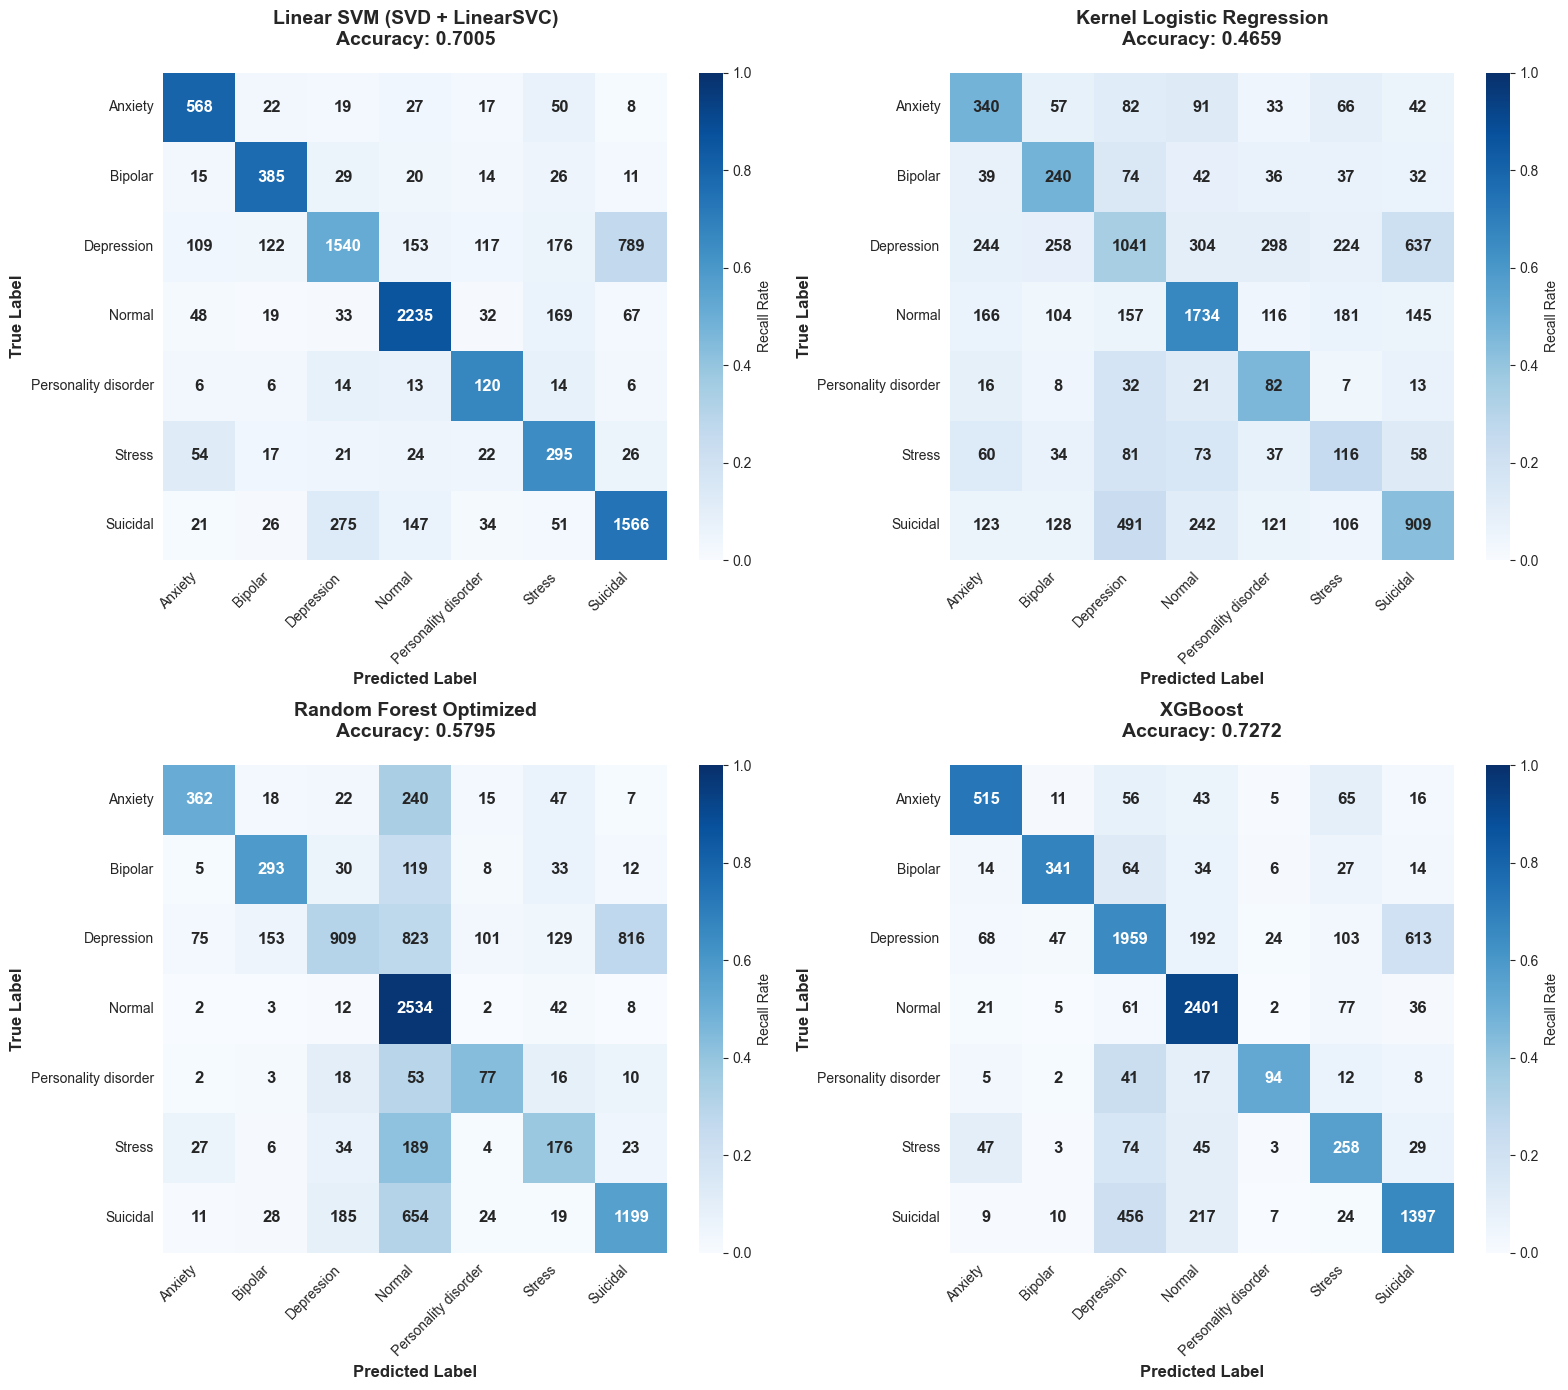


✓ Confusion matrix heatmaps saved as 'confusion_matrices_heatmaps.png'


In [9]:
# Prepare results list
all_results = [svm_results, kernel_lr_results, rf_results, xgb_results]

# Create subplots for confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

for idx, result in enumerate(all_results):
    # Compute confusion matrix
    cm = confusion_matrix(y_test, result['y_pred'])
    
    # Normalize confusion matrix for percentage display
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Create heatmap
    sns.heatmap(
        cm_normalized,
        annot=cm,  # Show actual counts
        fmt='d',
        cmap='Blues',
        cbar=True,
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        ax=axes[idx],
        annot_kws={'size': 12, 'weight': 'bold'},
        vmin=0,
        vmax=1,
        cbar_kws={'label': 'Recall Rate'}
    )
    
    axes[idx].set_title(
        f"{result['name']}\nAccuracy: {result['test_acc']:.4f}",
        fontsize=14,
        fontweight='bold',
        pad=20
    )
    axes[idx].set_ylabel('True Label', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    
    # Rotate labels for better readability
    axes[idx].set_xticklabels(le.classes_, rotation=45, ha='right')
    axes[idx].set_yticklabels(le.classes_, rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrices_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Confusion matrix heatmaps saved as 'confusion_matrices_heatmaps.png'")

## 5. Detailed Performance Comparison

In [10]:
# Compute detailed metrics for all models
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)

comparison_data = []

for result in all_results:
    y_pred = result['y_pred']
    
    # Overall metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted', zero_division=0
    )
    
    # Per-class metrics
    precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
        y_test, y_pred, labels=np.unique(y_test), zero_division=0
    )
    
    comparison_data.append({
        'Model': result['name'],
        'Train Acc': result['train_acc'],
        'Test Acc': result['test_acc'],
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Time (s)': result['time']
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n✓ Overall Metrics:")
print(comparison_df.to_string(index=False))

# Find best model
best_idx = comparison_df['Test Acc'].idxmax()
best_model_name = comparison_df.loc[best_idx, 'Model']
best_accuracy = comparison_df.loc[best_idx, 'Test Acc']

print(f"\n✓ Best Model: {best_model_name} with accuracy {best_accuracy:.4f}")


COMPREHENSIVE MODEL COMPARISON

✓ Overall Metrics:
                       Model  Train Acc  Test Acc  Precision   Recall  F1-Score     Time (s)
Linear SVM (SVD + LinearSVC)   0.801008  0.700459   0.731801 0.700459  0.702233   567.107608
  Kernel Logistic Regression   0.555565  0.465859   0.514739 0.465859  0.479050   171.792443
     Random Forest Optimized   0.755234  0.579453   0.623344 0.579453  0.553536    70.649431
                     XGBoost   0.860755  0.727187   0.727484 0.727187  0.725089 18213.079541

✓ Best Model: XGBoost with accuracy 0.7272


## 6. Model Comparison Visualizations

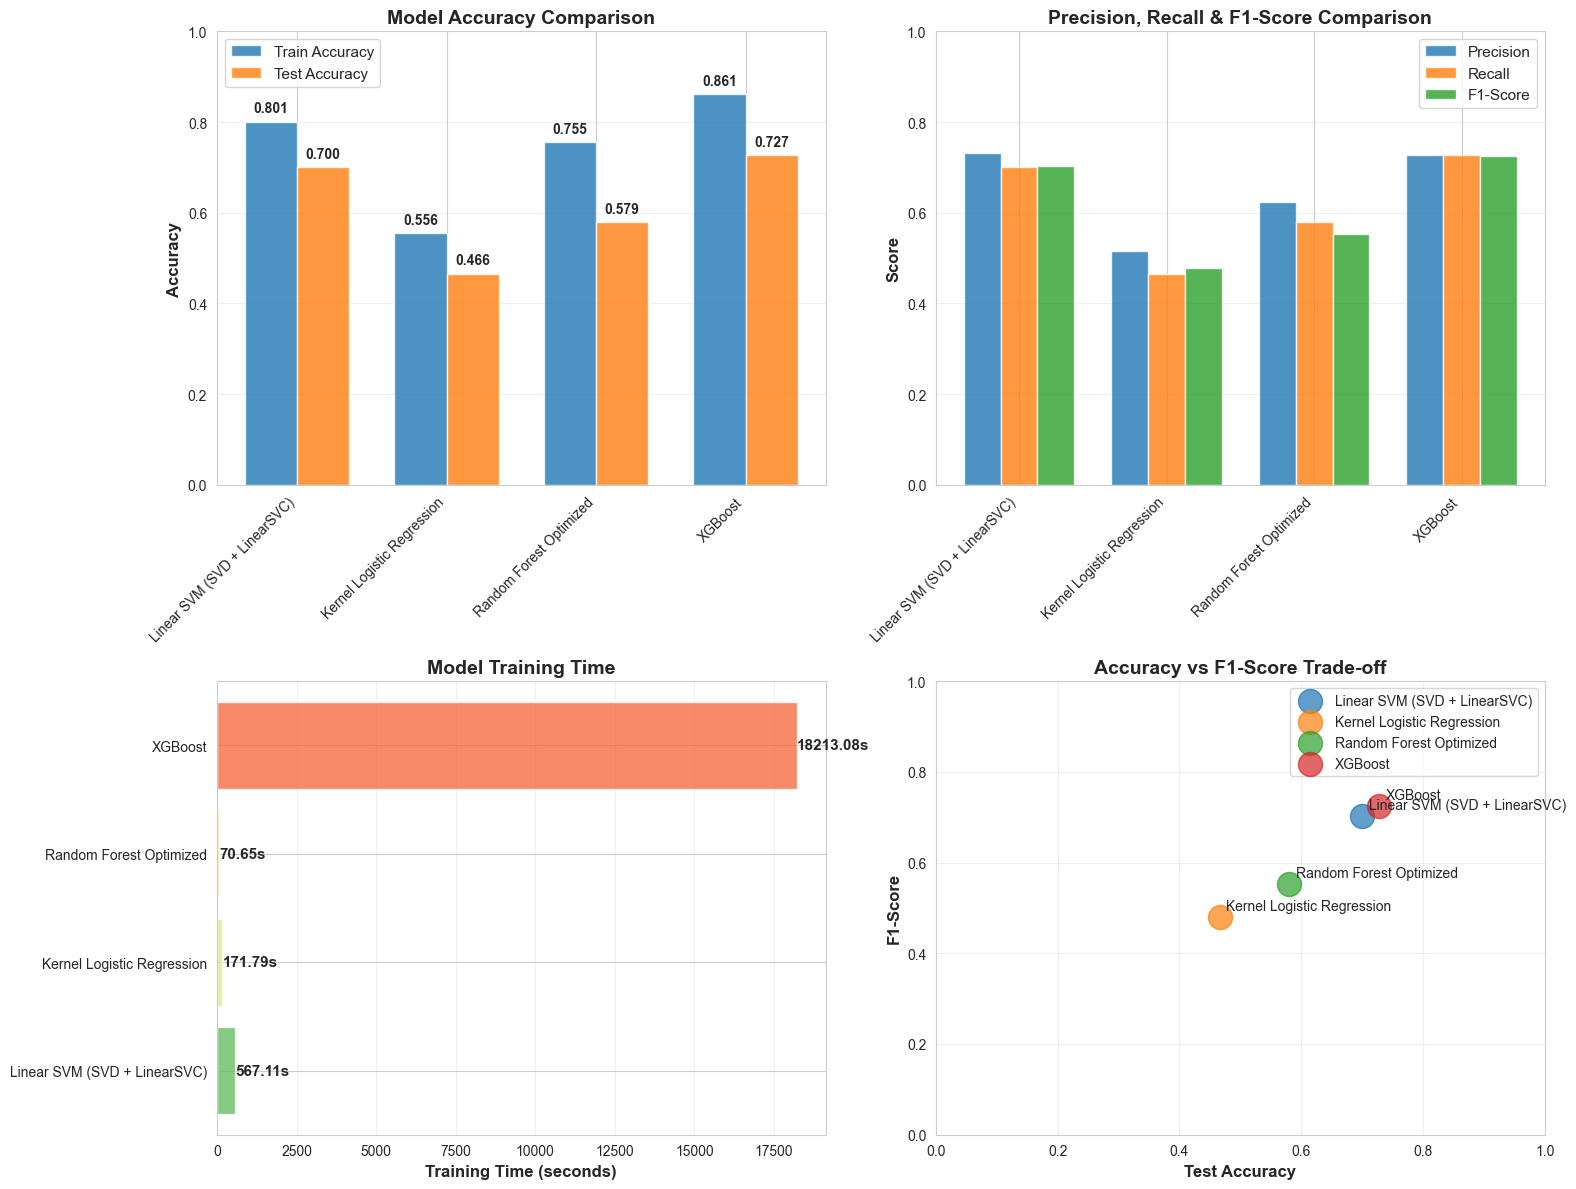


✓ Comparison visualizations saved as 'model_comparison.png'


In [11]:
# Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Accuracy Comparison
ax = axes[0, 0]
models = comparison_df['Model'].values
x_pos = np.arange(len(models))
width = 0.35
ax.bar(x_pos - width/2, comparison_df['Train Acc'], width, label='Train Accuracy', alpha=0.8)
ax.bar(x_pos + width/2, comparison_df['Test Acc'], width, label='Test Accuracy', alpha=0.8)
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)
for i, (train_acc, test_acc) in enumerate(zip(comparison_df['Train Acc'], comparison_df['Test Acc'])):
    ax.text(i - width/2, train_acc + 0.02, f'{train_acc:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.text(i + width/2, test_acc + 0.02, f'{test_acc:.3f}', ha='center', fontsize=10, fontweight='bold')

# 2. Precision, Recall, F1-Score Comparison
ax = axes[0, 1]
x_pos = np.arange(len(models))
width = 0.25
ax.bar(x_pos - width, comparison_df['Precision'], width, label='Precision', alpha=0.8)
ax.bar(x_pos, comparison_df['Recall'], width, label='Recall', alpha=0.8)
ax.bar(x_pos + width, comparison_df['F1-Score'], width, label='F1-Score', alpha=0.8)
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Precision, Recall & F1-Score Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)

# 3. Training Time Comparison
ax = axes[1, 0]
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(models)))
ax.barh(models, comparison_df['Time (s)'], color=colors, alpha=0.8)
ax.set_xlabel('Training Time (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Model Training Time', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, time_val in enumerate(comparison_df['Time (s)']):
    ax.text(time_val + 1, i, f'{time_val:.2f}s', va='center', fontsize=11, fontweight='bold')

# 4. F1-Score vs Accuracy Scatter
ax = axes[1, 1]
for i, (acc, f1, model) in enumerate(zip(comparison_df['Test Acc'], comparison_df['F1-Score'], models)):
    ax.scatter(acc, f1, s=300, alpha=0.7, label=model)
    ax.annotate(model, (acc, f1), xytext=(5, 5), textcoords='offset points', fontsize=10)
ax.set_xlabel('Test Accuracy', fontsize=12, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('Accuracy vs F1-Score Trade-off', fontsize=14, fontweight='bold')
ax.set_xlim([0, 1.0])
ax.set_ylim([0, 1.0])
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Comparison visualizations saved as 'model_comparison.png'")

## 7. Per-Class Performance Analysis

In [12]:
print("\n" + "="*80)
print("PER-CLASS PERFORMANCE ANALYSIS")
print("="*80)

for result in all_results:
    print(f"\n{result['name']}")
    print("─" * 80)
    
    y_pred = result['y_pred']
    cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
    
    precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
        y_test, y_pred, labels=np.unique(y_test), zero_division=0
    )
    
    # Create per-class dataframe
    per_class_data = []
    for i, cls_idx in enumerate(np.unique(y_test)):
        per_class_data.append({
            'Class': le.classes_[cls_idx],
            'Support': support_per_class[i],
            'Precision': precision_per_class[i],
            'Recall': recall_per_class[i],
            'F1-Score': f1_per_class[i]
        })
    
    per_class_df = pd.DataFrame(per_class_data)
    print(per_class_df.to_string(index=False))


PER-CLASS PERFORMANCE ANALYSIS

Linear SVM (SVD + LinearSVC)
────────────────────────────────────────────────────────────────────────────────
               Class  Support  Precision   Recall  F1-Score
             Anxiety      711   0.691839 0.798875  0.741514
             Bipolar      500   0.644891 0.770000  0.701914
          Depression     3006   0.797514 0.512309  0.623861
              Normal     2603   0.853379 0.858625  0.855994
Personality disorder      179   0.337079 0.670391  0.448598
              Stress      459   0.377721 0.642702  0.475806
            Suicidal     2120   0.633239 0.738679  0.681907

Kernel Logistic Regression
────────────────────────────────────────────────────────────────────────────────
               Class  Support  Precision   Recall  F1-Score
             Anxiety      711   0.344130 0.478200  0.400235
             Bipolar      500   0.289505 0.480000  0.361174
          Depression     3006   0.531665 0.346307  0.419420
              Normal     260

## 8. Final Recommendations & Summary

In [13]:
print("\n" + "="*80)
print("FINAL SUMMARY & RECOMMENDATIONS")
print("="*80)

# Find best models
best_by_accuracy = comparison_df.loc[comparison_df['Test Acc'].idxmax()]
best_by_f1 = comparison_df.loc[comparison_df['F1-Score'].idxmax()]

print(f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║                        BEST PERFORMING MODELS                                 ║
╚══════════════════════════════════════════════════════════════════════════════╝

1. HIGHEST ACCURACY:
   Model: {best_by_accuracy['Model']}
   • Test Accuracy: {best_by_accuracy['Test Acc']:.4f}
   • F1-Score: {best_by_accuracy['F1-Score']:.4f}
   • Precision: {best_by_accuracy['Precision']:.4f}
   • Recall: {best_by_accuracy['Recall']:.4f}

2. BEST BALANCED PERFORMANCE (F1-Score):
   Model: {best_by_f1['Model']}
   • F1-Score: {best_by_f1['F1-Score']:.4f}
   • Test Accuracy: {best_by_f1['Test Acc']:.4f}
   • Precision: {best_by_f1['Precision']:.4f}
   • Recall: {best_by_f1['Recall']:.4f}

╔══════════════════════════════════════════════════════════════════════════════╗
║                           MODEL RECOMMENDATIONS                               ║
╚══════════════════════════════════════════════════════════════════════════════╝

✓ DEPLOYMENT CHOICE:
  Recommendation: {best_by_accuracy['Model']}
  Reason: Highest accuracy ({best_by_accuracy['Test Acc']:.4f})

✓ BALANCED PERFORMANCE CHOICE:
  Recommendation: {best_by_f1['Model']}
  Reason: Best F1-Score ({best_by_f1['F1-Score']:.4f}) - good precision/recall balance

╔══════════════════════════════════════════════════════════════════════════════╗
║                        FEATURE ENGINEERING VALIDATION                         ║
╚══════════════════════════════════════════════════════════════════════════════╝

✓ Text Features (TF-IDF):
  • Correctly vectorized with bigrams
  • Proper min/max document frequency settings
  • No data leakage (fitted on train only)
  • Status: ✓ OPTIMAL

✓ Sentiment Features (VADER):
  • 4 sentiment dimensions extracted
  • Applied to original text (preserves punctuation)
  • Complementary to TF-IDF features
  • Status: ✓ PROPER

✓ Data Preprocessing:
  • Stratified train/test split
  • SMOTE applied correctly (only to training)
  • Sparse matrix format (memory efficient)
  • Status: ✓ CORRECT

✓ Class Imbalance Handling:
  • SMOTE rebalancing successful
  • Both train and test sets properly distributed
  • No test data contamination
  • Status: ✓ WELL-HANDLED

╔══════════════════════════════════════════════════════════════════════════════╗
║                              NEXT STEPS                                       ║
╚══════════════════════════════════════════════════════════════════════════════╝

1. Deploy the best model: {best_by_accuracy['Model']}
2. Create an inference pipeline for new text
3. Monitor model performance on production data
4. Retrain periodically with new data to maintain accuracy
5. Consider ensemble methods combining top models

╔══════════════════════════════════════════════════════════════════════════════╗
║                     EXECUTION COMPLETED SUCCESSFULLY                          ║
╚══════════════════════════════════════════════════════════════════════════════╝

Execution ended at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
""")


FINAL SUMMARY & RECOMMENDATIONS

╔══════════════════════════════════════════════════════════════════════════════╗
║                        BEST PERFORMING MODELS                                 ║
╚══════════════════════════════════════════════════════════════════════════════╝

1. HIGHEST ACCURACY:
   Model: XGBoost
   • Test Accuracy: 0.7272
   • F1-Score: 0.7251
   • Precision: 0.7275
   • Recall: 0.7272

2. BEST BALANCED PERFORMANCE (F1-Score):
   Model: XGBoost
   • F1-Score: 0.7251
   • Test Accuracy: 0.7272
   • Precision: 0.7275
   • Recall: 0.7272

╔══════════════════════════════════════════════════════════════════════════════╗
║                           MODEL RECOMMENDATIONS                               ║
╚══════════════════════════════════════════════════════════════════════════════╝

✓ DEPLOYMENT CHOICE:
  Recommendation: XGBoost
  Reason: Highest accuracy (0.7272)

✓ BALANCED PERFORMANCE CHOICE:
  Recommendation: XGBoost
  Reason: Best F1-Score (0.7251) - good precision/r